# Задание Pro

Решите задачу по распознаванию позитивных и негативных отзывы людей по автомобилю Tesla. База для обучения содержит два текстовых файла с рядом строчных отзывов с мнением людей об автомобиле Tesla, соответственно негативного и позитивного содержания. Ссылка на скачивание базы уже включена в ноутбук задания.


Необходимо выполнить следующие действия:

  1. Загрузите саму базу по ссылке и подговьте файлы базы для обработки.
  2. Создайте обучающую и проверочную выборки, обратив особое внимание на балансировку базы: количество примеров каждого класса должно быть примерно одного порядка.
  3. Подготовьте выборки для обучения и обучите сеть. Добейтесь результата точности сети в 85-90% на проверочной выборке.
   


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import gdown
import os
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/tesla.zip', None, quiet=True)

'tesla.zip'

In [3]:
!unzip -qo tesla.zip -d tesla/
!ls tesla

'Негативный отзыв.txt'	'Позитивный отзыв.txt'


In [4]:
# Функция для чтения файла
def read_text(file_name):

  read_file = open(file_name, 'r', encoding='utf-8')
  text = read_file.read()

  text = text.replace("\n", " ")

  return text

class_names = ["Негативный отзыв", "Позитивный отзыв"]

num_classes = len(class_names)

In [5]:
import os
# Создаём список под тексты для обучающей выборки
texts_list = []

for j in os.listdir('/content/tesla/'):

        texts_list.append(read_text('/content/tesla/' + j))

        print(j, 'добавлен в обучающую выборку')

Позитивный отзыв.txt добавлен в обучающую выборку
Негативный отзыв.txt добавлен в обучающую выборку


In [6]:
# Узнаем объём каждого текста в словах и символах
texts_len = [len(text) for text in texts_list]

t_num = 0

print(f'Размеры текстов по порядку (в токенах):')

# Циклом проводим итерацию по списку с объёмами текстов
for text_len in texts_len:

  t_num += 1

  print(f'Текст №{t_num}: {text_len}')

Размеры текстов по порядку (в токенах):
Текст №1: 213381
Текст №2: 134535


In [7]:
# Создаём список
train_len_shares = [(i - round(i/5)) for i in texts_len]

t_num = 0

# Циклом проводим итерацию по списку с объёмами текстов
for train_len_share in train_len_shares:

  t_num += 1

  print(f'Доля 80% от текста №{t_num}: {train_len_share} символов')

Доля 80% от текста №1: 170705 символов
Доля 80% от текста №2: 107628 символов


In [8]:
from itertools import chain

# списки для обучающих текстов
train_texts = []
test_texts = []

for i in range(num_classes):

  train_texts.append(texts_list[i][:train_len_shares[i]])

  test_texts.append(texts_list[i][train_len_shares[i]:])

# проверка размеров выборок
for i in range(num_classes):
  print(class_names[i])
  print('Обучающий текст:', len(train_texts[i]))
  print('Проверочный текст:', len(test_texts[i]))
  print()

Негативный отзыв
Обучающий текст: 170705
Проверочный текст: 42676

Позитивный отзыв
Обучающий текст: 107628
Проверочный текст: 26907



In [9]:
# параметры
vocab_size = 20000
win_size = 1000
win_hop = 100

# создание токенов
tokenizer = Tokenizer(num_words=vocab_size, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n\xa0', lower=True, split=' ', oov_token='unknown', char_level=False)
tokenizer.fit_on_texts(train_texts) # обучение
train_word_indexes = tokenizer.texts_to_sequences(train_texts)
test_word_indexes = tokenizer.texts_to_sequences(test_texts)

for i in range(num_classes):
  print(class_names[i])
  print('Обучающая последовательность:', len(train_word_indexes[i]))
  print('Проверочная последовательность:', len(test_word_indexes[i]))
  print()

Негативный отзыв
Обучающая последовательность: 25895
Проверочная последовательность: 6634

Позитивный отзыв
Обучающая последовательность: 16962
Проверочная последовательность: 4328



In [10]:

def vectorize_sequence(sequence, vocab_size):

  x = np.zeros(vocab_size)

  for word_index in sequence:

    if word_index < vocab_size:

      x[word_index] = 1

  return x

# функция создает обучающую или проверочную выборку
def create_bow_dataset(word_indexes, num_classes, vocab_size, win_size, win_hop):

  # входные данные
  x_data = []

  # правильные ответы
  y_data = []

  # проходим по каждому классу
  for class_index in range(num_classes):

    sequence = word_indexes[class_index]

    for start in range(0, len(sequence) - win_size, win_hop):

      # берется кусок текста
      window = sequence[start:start + win_size]

      x_data.append(vectorize_sequence(window, vocab_size))

      y_data.append(class_index)

  x_data = np.array(x_data)
  y_data = np.array(y_data)

  y_data = utils.to_categorical(y_data, num_classes)

  return x_data, y_data

In [11]:
# создание обучающей выборки
x_train, y_train = create_bow_dataset(train_word_indexes, num_classes, vocab_size, win_size, win_hop)

# создание проверочной выборки
x_test, y_test = create_bow_dataset(test_word_indexes, num_classes, vocab_size, win_size, win_hop)

# проверка размеров выборок
print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_test:', x_test.shape)
print('y_test:', y_test.shape)

# фукнция для балансировки выборки
def balance_dataset(x_data, y_data):

  y_classes = np.argmax(y_data, axis=1)

  # подсчет количества примеров каждого класса
  class_counts = []

  for i in range(num_classes):
    class_counts.append(np.sum(y_classes == i))

  # берется минимальное количество примеров среди классов
  min_count = min(class_counts)

  balanced_indexes = []

  random_state = np.random.RandomState(42)

  for i in range(num_classes):

    class_indexes = np.where(y_classes == i)[0]
    random_state.shuffle(class_indexes)
    class_indexes = class_indexes[:min_count]
    balanced_indexes.extend(class_indexes)

  balanced_indexes = np.array(balanced_indexes)

  random_state.shuffle(balanced_indexes)

  return x_data[balanced_indexes], y_data[balanced_indexes]

# балансировка обучающей выборки
x_train, y_train = balance_dataset(x_train, y_train)

# балансировка проверочной выборки
x_test, y_test = balance_dataset(x_test, y_test)

# проверка размеров выборок
print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_test:', x_test.shape)
print('y_test:', y_test.shape)

print('Примеры по классам в обучении:', y_train.sum(axis=0))
print('Примеры по классам в проверке:', y_test.sum(axis=0))

x_train: (409, 20000)
y_train: (409, 2)
x_test: (91, 20000)
y_test: (91, 2)
x_train: (320, 20000)
y_train: (320, 2)
x_test: (68, 20000)
y_test: (68, 2)
Примеры по классам в обучении: [160. 160.]
Примеры по классам в проверке: [34. 34.]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9500 - loss: 0.1123 - val_accuracy: 0.8529 - val_loss: 0.2749
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 1.3943e-04 - val_accuracy: 0.9118 - val_loss: 0.2049
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 9.7210e-05 - val_accuracy: 0.9412 - val_loss: 0.1604
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 1.0593e-04 - val_accuracy: 0.9412 - val_loss: 0.1227
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 2.3365e-05 - val_accuracy: 0.9412 - val_loss: 0.1125
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.5610e-04 - val_accuracy: 0.9412 - val_loss: 0.0846
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.1215e-05 - val_accuracy: 0.9559 - val_loss: 0.0713
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 2.5857e-05 - val

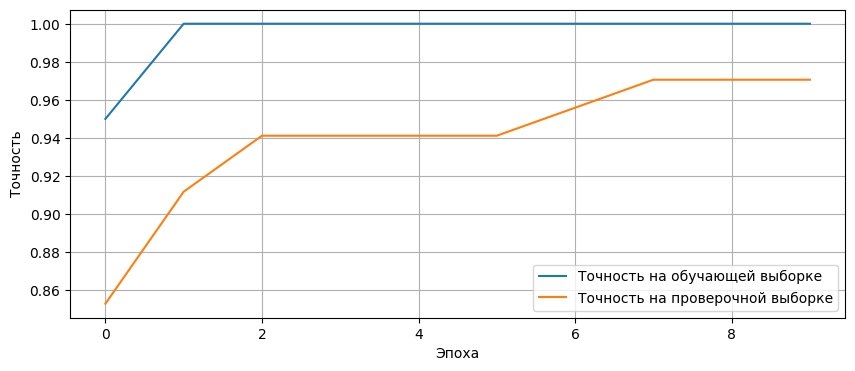

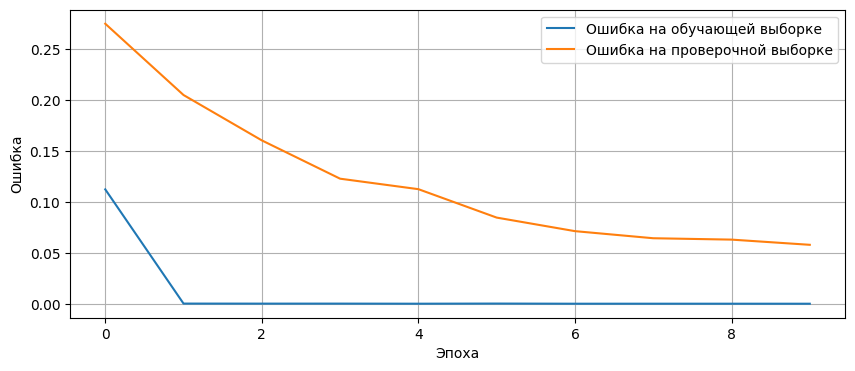

In [12]:
# создание модели
model = Sequential()

model.add(Dense(128, input_dim=vocab_size, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

# компиляция модели
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# обучение
history = model.fit(x_train, y_train, epochs=10, batch_size=8, validation_data=(x_test, y_test), verbose=1)

# оценка
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print('Ошибка на проверочной выборке:', test_loss)
print('Точность на проверочной выборке:', test_accuracy)

# графики обучения и ошибки
plt.figure(figsize=(10, 4))

plt.plot(history.history['accuracy'], label='Точность на обучающей выборке')
plt.plot(history.history['val_accuracy'], label='Точность на проверочной выборке')

plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 4))

plt.plot(history.history['loss'], label='Ошибка на обучающей выборке')
plt.plot(history.history['val_loss'], label='Ошибка на проверочной выборке')

plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.legend()
plt.grid()
plt.show()